# Project - Big Data Deep Learning


---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre** | Recuay Denegri Briggitt |
| **Título del Proyecto** | Predicción de incumplimiento de préstamos usando datos de Kaggle con regresión logística y MLP|




---

## Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)


---
## 1. Resumen Ejecutivo

- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---

El proyecto analiza datos de préstamos financieros obtenidos de la plataforma Kaggle con el objetivo de reducir el riesgo de impago y mejorar la toma de decisiones crediticias en instituciones financieras. El problema de negocio se centra en identificar de forma anticipada a los clientes con mayor probabilidad de incumplir sus pagos, ya que los impagos representan pérdidas económicas significativas. Para abordarlo, se aplicó una metodología de análisis de datos que incluyó la exploración del conjunto de datos, limpieza y preparación de la información, análisis descriptivo de variables clave como ingresos, monto del préstamo, historial crediticio y características demográficas, así como la identificación de patrones entre clientes cumplidos y morosos. En una etapa posterior, estos análisis pueden complementarse con modelos de aprendizaje automático para predecir el riesgo de impago de nuevos solicitantes. Los principales hallazgos muestran que los clientes con menores ingresos, mayor proporción de deuda respecto a su salario y antecedentes crediticios negativos presentan una probabilidad significativamente mayor de incumplimiento, mientras que perfiles financieros más estables tienden a cumplir con sus obligaciones. Como impacto esperado en el negocio, este enfoque permite reducir pérdidas financieras, optimizar los criterios de aprobación de créditos, focalizar acciones preventivas en clientes de alto riesgo y automatizar procesos de evaluación crediticia, logrando una gestión más eficiente y rentable del portafolio de préstamos.





---

## 2. Configuración del Entorno



### 2.1 Instalación de Librerías Adicionales (si es necesario)

In [2]:
import kagglehub
import os
import keras


### 2.2 Importación de Librerías

In [3]:
# =====================================================
# LIBRERÍAS FUNDAMENTALES
# =====================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de patrones de impago
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelo de machine learning - Redes neuronales (MLP)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Modelos de machine learning (clasificación de riesgo)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelos de regresión logística(evaluación de variables x)
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Evaluación del modelo
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Utilidades
import warnings
warnings.filterwarnings('ignore')

### 2.3 Conexión con Google Drive (para cargar datos)

In [4]:
# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-default' dataset.
Path to dataset files: /kaggle/input/loan-default


In [5]:
os.listdir(path)

['Loan_default.csv']

---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

---

El proyecto se sitúa en el sector financiero, específicamente en servicios de préstamos. El caso de estudio utiliza un dataset de Kaggle que simula operaciones reales de crédito. La situación actual muestra la necesidad de reducir impagos mediante análisis de datos y modelos predictivos que mejoren la evaluación de riesgo y la toma de decisiones crediticias.



---

### 3.2 Problema a Resolver

---

El problema consiste en la dificultad de predecir correctamente el impago de préstamos. Es importante resolverlo para reducir pérdidas financieras y mejorar la toma de decisiones crediticias. Actualmente, los incumplimientos generan altos costos, menor rentabilidad y procesos de cobranza ineficientes.

---

### 3.3 Objetivos del Proyecto

---

**Objetivo General:**

Predecir el riesgo de impago para mejorar decisiones crediticias.

**Objetivos Específicos:**
1. Limpiar y preparar el 100% del dataset de préstamos para su análisis y modelado.

2. Identificar las principales variables que influyen en el impago mediante análisis exploratorio de datos.

3. Construir y evaluar al menos dos modelos predictivos de riesgo crediticio usando métricas de desempeño.

4. Alcanzar una precisión mínima del 75% en la predicción de incumplimiento de pagos.

5. Generar visualizaciones que respalden la toma de decisiones del negocio.

---

### 3.4 Tipo de Problema de Machine Learning

- Clasificación binaria

**Justificación:**
El modelo busca predecir solo dos resultados posibles:

• ✅ Paga el préstamo
• ❌ No paga el préstamo

---

---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-default' dataset.
Path to dataset files: /kaggle/input/loan-default


In [7]:
import os
print(os.listdir(path))

['Loan_default.csv']


In [8]:
# =====================================================
# CARGA DE DATOS

df = pd.read_csv("/kaggle/input/loan-default/Loan_default.csv")

print(" Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

 Dataset cargado exitosamente
   Dimensiones: 255,347 filas × 18 columnas


### 4.2 Descripción del Dataset

- Fuente de los datos: Kaggle.
- Período de tiempo que cubren: Registros históricos de clientes de préstamos financieros (múltiples periodos de otorgamiento y pago).
- Tamaño del conjunto de datos: 255,347 filas y 18 columnas.

---
- Descripción de cada variable

| Column | Tipo | Descripción |
|----------|------|-------------|
| LoanID | object | ID del préstamo |
| Age | Categórica   | Edad |
| Income | numérica | Ingresos|
| LoanAmount | numérica | Monto del préstamo |
| CreditScore | numérica | Calificación crediticia |  
| MonthsEmployed | numérica | Meses de empleo |
| NumCreditLines | numérica | Número de líneas de crédito |
| InterestRate | numérica | Tasa de interés |
| LoanTerm | numérica | Plazo del préstamo |  
| DTIRatio | numérica | Relación DTI |
| Education | Categórica | Educación |
| EmploymentType | Categórica | Tipo de empleo |
| MaritalStatus | Categórica | Estado civil |
| HasMortgage | Categórica | Tiene hipoteca |
| HasDependents | Categórica | Tiene dependientes |
| LoanPurpose | Categórica | Propósito del préstamo |
| HasCoSigner | Categórica | Tiene avalista |
| Default | Categórica binaria | Incumplimiento en el pago (1 = sí, 0 = no) | #es el target

---

### 4.3 Exploración Inicial de Datos (EDA)

In [16]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

 Primeras 5 filas:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0



 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-nu

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [17]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES
\ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: Default

 Distribución de clases:
Default
0    225694
1     29653
Name: count, dtype: int64


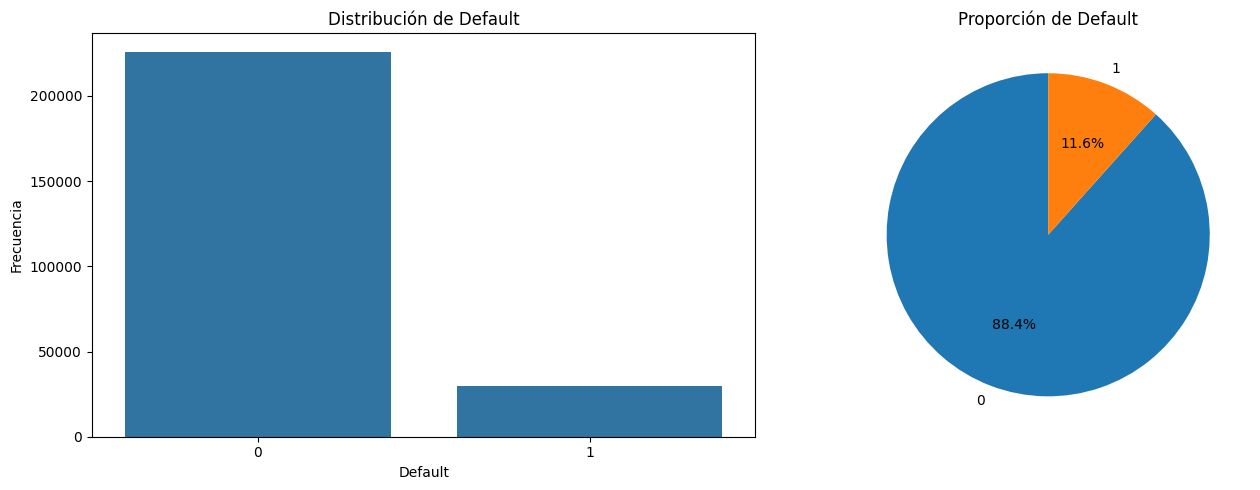


 ADVERTENCIA: Dataset desbalanceado (ratio 7.61:1)
   Considere técnicas de balanceo: SMOTE, undersampling, class weights


In [18]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# Especificar el nombre de la variable objetivo
TARGET_COLUMN = 'Default'

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

MATRIZ DE CORRELACIONES


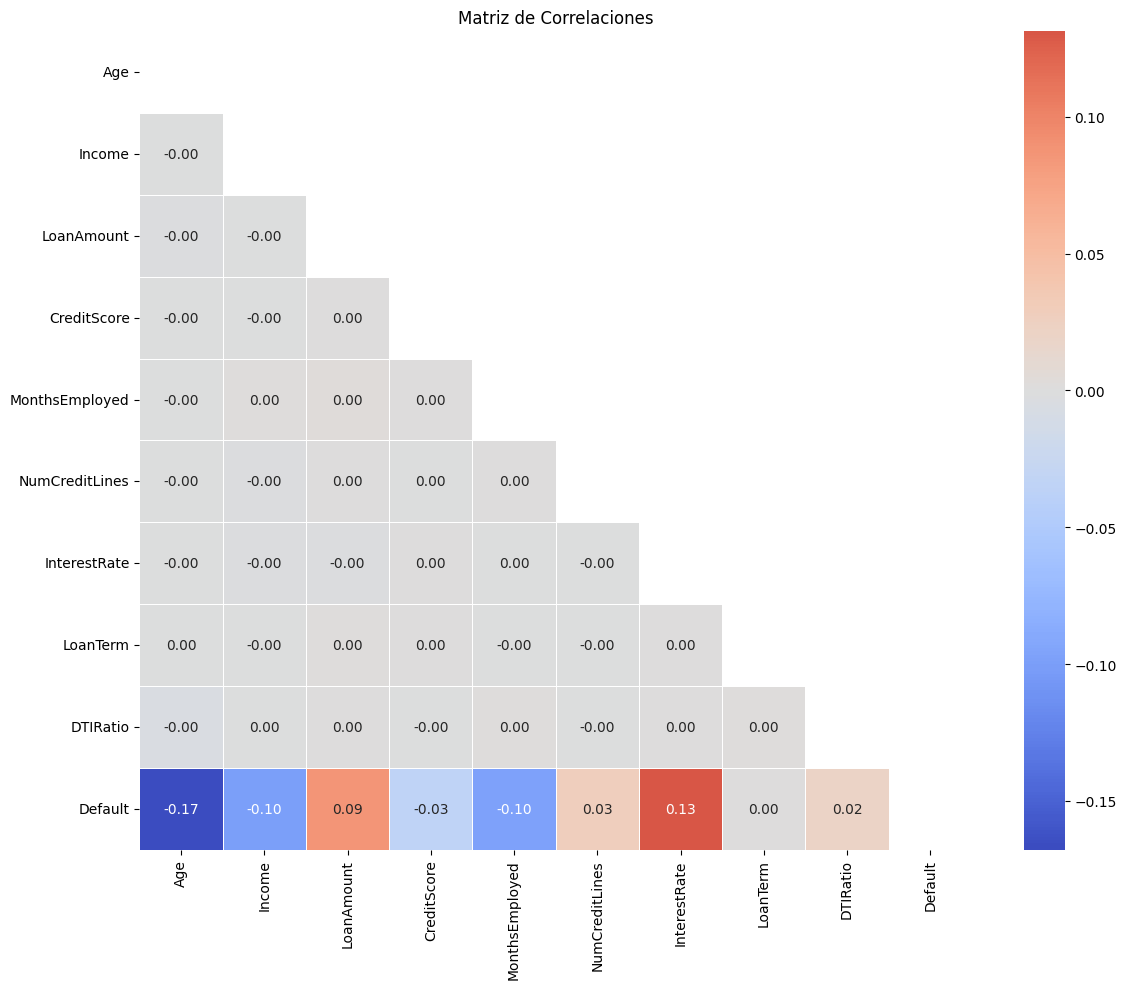


📊 Correlaciones con Default:
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64


In [ ]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

VISUALIZACIONES ADICIONALES


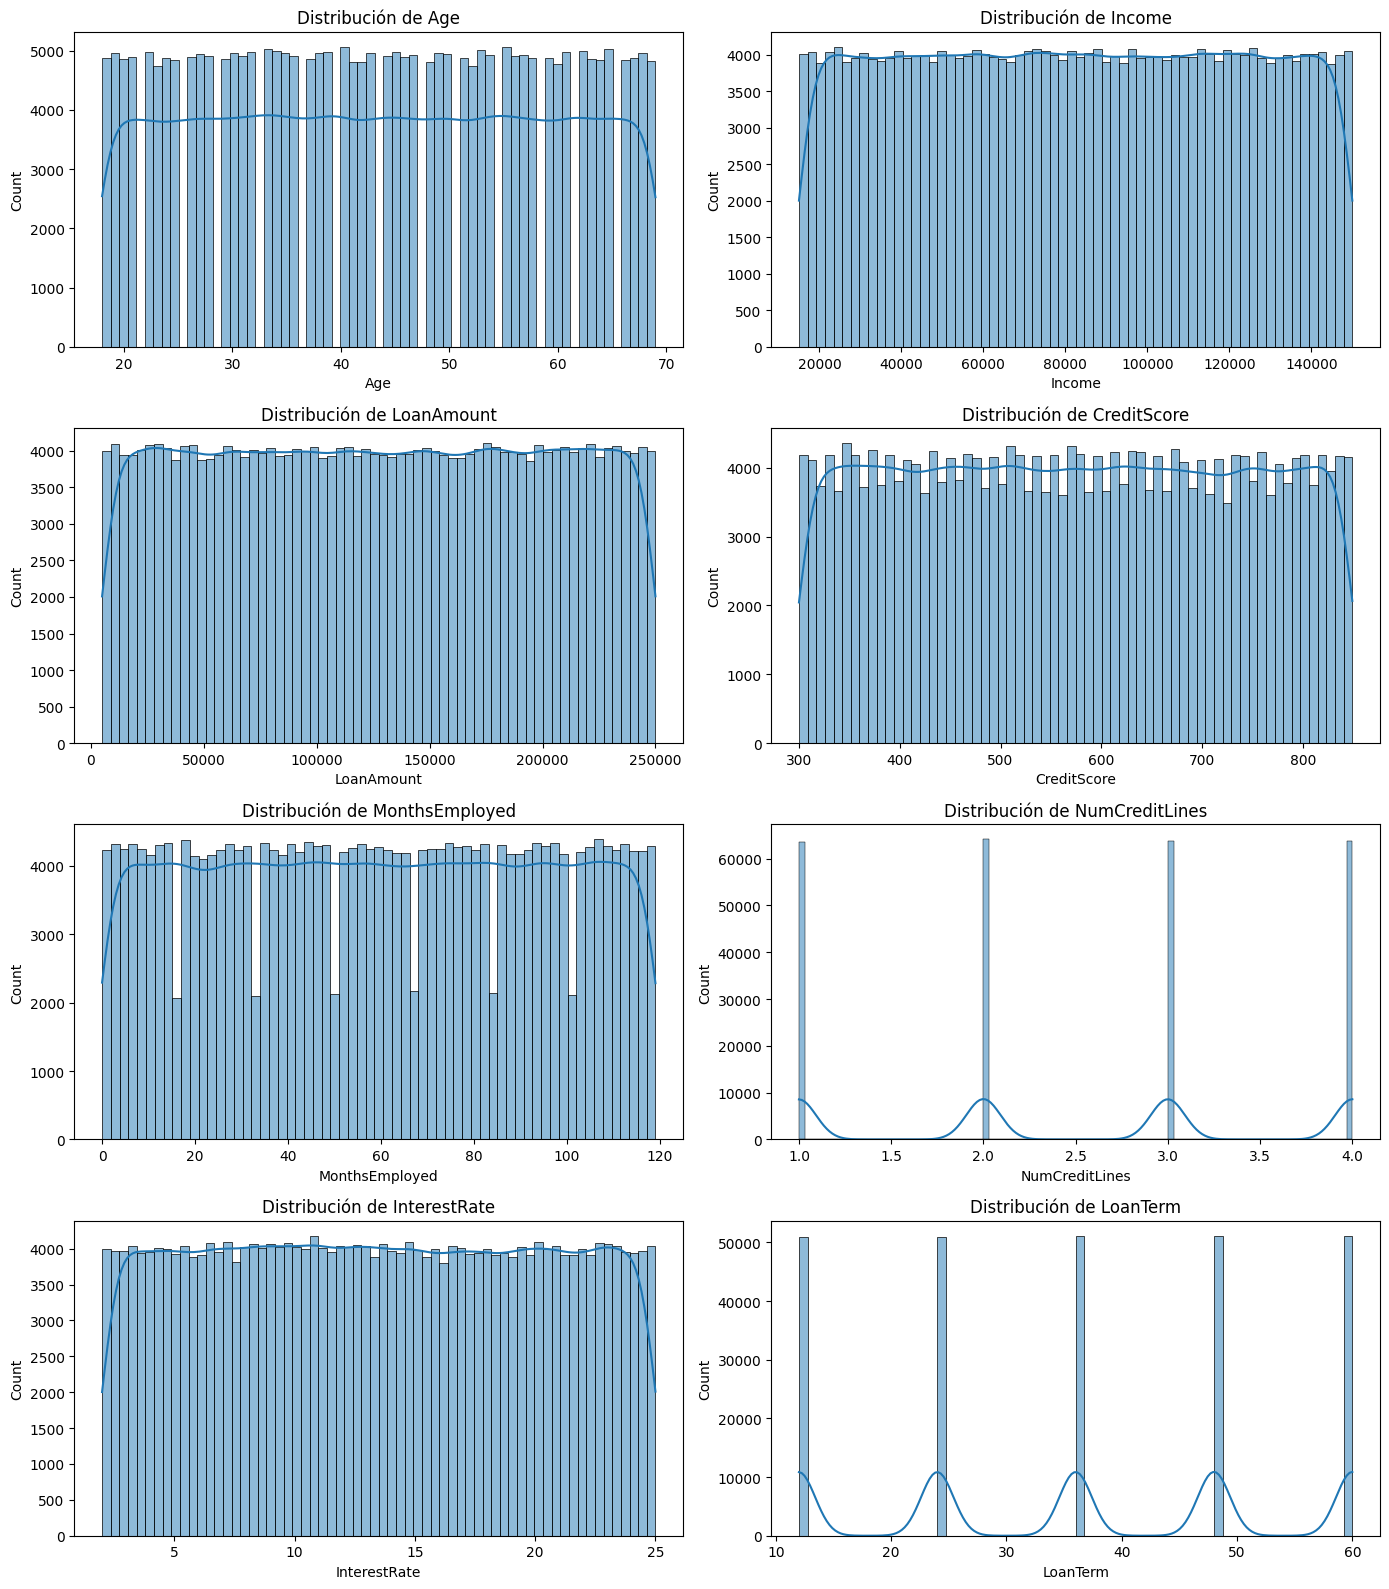

In [ ]:
# =====================================================
# VISUALIZACIONES ADICIONALES
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:8]  # Primeras 8 columnas

if len(numeric_cols_plot) > 0:
    n_cols = 2
    n_rows = (len(numeric_cols_plot) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, col in enumerate(numeric_cols_plot):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.4 Hallazgos del EDA


---

**Hallazgos Principales:**
1. Las variables numéricas en su mayoría presentan una distribución relativamente uniforme.
2. No hay correlaciones muy marcadas, pero si se debe resaltar el ratio de interes y el ingreso, presentan correlación positiva y la "edad" una correlación negativa, lo cuál es lógico a más edad mayor será el incumplimiento en los pagos.


**Problemas Identificados:**
1. No hay información sobre patrones que expliquen por qué se incumple.
2. Hay desbalanceo en nuestros datos tenemos que el 11.6% incumple los pagos, una razón de 9/1 altamente desbalanceado. N

**Acciones a Tomar:**
1. Debido a la gran diferencia en la magnitud de las variables, se realizará un escalado de las características.

2. Se aplicará one hot enconding (get-dummies) ya que se cuenta con variables categóricas.

3. Desarrollar un modelo predictivo que estime la probabilidad de incumplimiento utilizando Machine Learning.


---

---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

In [19]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de imputación
# =====================================================



print(f"\n Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES

 Valores faltantes tratados
   Filas restantes: 255,347


### 5.2 Tratamiento de Outliers

In [20]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,Default,29653,11.61,0.0,0.0


In [ ]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (En caso existan, es OPCIONAL)
# =====================================================

# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in cols_to_transform:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================




### 5.3 Codificación de Variables Categóricas

In [21]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables categóricas encontradas: {categorical_cols}")

# Opción 1: Label Encoding (para variables ordinales o target)
# le = LabelEncoder()
# df_clean['columna_encoded'] = le.fit_transform(df_clean['columna'])

# Opción 2: One-Hot Encoding (para variables nominales)
# df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Opción 3: Target Encoding
# from sklearn.preprocessing import TargetEncoder
# encoder = TargetEncoder()
# df_clean[categorical_cols] = encoder.fit_transform(df_clean[categorical_cols], df_clean[TARGET_COLUMN])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de codificación
# =====================================================



print(f"\n Codificación completada")
print(f"   Dimensiones finales: {df_clean.shape}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Variables categóricas encontradas: ['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

 Codificación completada
   Dimensiones finales: (255347, 18)


### 5.4 Escalado/Normalización de Features

In [22]:
# =====================================================
# ESCALADO DE FEATURES
# =====================================================

print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

from sklearn.preprocessing import StandardScaler

# 1.1 Separar target
y = df_clean[TARGET_COLUMN]
print(y.value_counts())
print(y.value_counts(normalize=True))

# 1.2 Separar features (sin target y sin LoanID)
X = df_clean.drop(columns=[TARGET_COLUMN, "LoanID"])

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")


# 2. Convertir categóricas a dummies
X = pd.get_dummies(X, drop_first=True)
print("Dimensiones después de get_dummies:", X.shape)

# 3. Escalar solo columnas numéricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


# Aplicar escalado
X_scaled = X.copy()

print(f"\n Escalado completado usando {type(scaler).__name__}")
print(f"   Media de features: {X_scaled.mean().mean():.6f}")
print(f"   Std de features: {X_scaled.std().mean():.6f}")


ESCALADO DE FEATURES
Default
0    225694
1     29653
Name: count, dtype: int64
Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

Dimensiones de X: (255347, 16)
Dimensiones de y: (255347,)
Dimensiones después de get_dummies: (255347, 24)

 Escalado completado usando StandardScaler
   Media de features: 0.186121
   Std de features: 0.651704


In [ ]:
print(X.columns)
print(len(X.columns))

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
       'Education_High School', 'Education_Master's', 'Education_PhD',
       'EmploymentType_Part-time', 'EmploymentType_Self-employed',
       'EmploymentType_Unemployed', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes',
       'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home',
       'LoanPurpose_Other', 'HasCoSigner_Yes'],
      dtype='object')
24


### 5.5 División de Datos (Train/Validation/Test)

In [23]:
# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

RANDOM_SEED = 42  # definir semilla aleatoria

# Primero: separar test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y
)

# Separar train (70%) y validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # ≈ 15% del total
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f"\n División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Verificar distribución de clases (para clasificación)
if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n Distribución de clases en cada conjunto:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

DIVISIÓN DE DATOS

 División de datos:
   Training set:   178,844 muestras (70.0%)
   Validation set: 38,200 muestras (15.0%)
   Test set:       38,303 muestras (15.0%)

 Distribución de clases en cada conjunto:
   Train: {0: np.float64(0.884), 1: np.float64(0.116)}
   Val:   {0: np.float64(0.884), 1: np.float64(0.116)}
   Test:  {0: np.float64(0.884), 1: np.float64(0.116)}


### 5.6 Preparación de Datos para Deep Learning

In [24]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

from tensorflow import keras

# Número de clases
num_classes = y.nunique()  # debería ser 2 para tu target binario

# Convertir y a numpy SIN one-hot
y_train_np = y_train.values.astype('float32')
y_val_np   = y_val.values.astype('float32')
y_test_np  = y_test.values.astype('float32')

# Convertir X a numpy float32
X_train_np = X_train.values.astype('float32')
X_val_np   = X_val.values.astype('float32')
X_test_np  = X_test.values.astype('float32')

print(f"Shape X_train: {X_train_np.shape}")
print(f"Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS
Shape X_train: (178844, 24)
Shape y_train: (178844,)


---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

- Elegí usar una red neuronal feedforward (MLP) porque el problema es de clasificación binaria con datos estructurados. Se empleó ReLU por eficiencia computacional y Sigmoid en la salida porque el problema es binario.


- Consideré otras alternativas que se adecuaban mejor cómo la Random Forest, XGBoost y la LightGBM generan menos esfuerzo.

- Se utilizaron dos capas porque permiten modelar relaciones no lineales entre variables financieras sin introducir una complejidad excesiva que aumente el riesgo de sobreajuste.


---

### 6.2 Definición del Modelo

In [25]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS
# =====================================================

def create_keras_model(input_shape, hidden_sizes, dropout_rate=0.3, task='classification'):
    """
    Crea un modelo de red neuronal con Keras.

    Args:
        input_shape: Dimensión de entrada
        hidden_sizes: Lista con el número de neuronas por capa oculta
        dropout_rate: Tasa de dropout
        task: 'classification' o 'regression'
    """
    model = keras.Sequential()

    # Capa de entrada
    model.add(keras.layers.Input(shape=(input_shape,)))

    # Capas ocultas
    for hidden_size in hidden_sizes:
        model.add(keras.layers.Dense(hidden_size))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dropout(dropout_rate))

    # Capa de salida
    if task == 'classification':
        # Clasificación binaria → 1 neurona + sigmoid
        model.add(keras.layers.Dense(1, activation='sigmoid'))
    else:
        # Regresión
        model.add(keras.layers.Dense(1, activation='linear'))

    return model

# Crear modelo Keras
TASK = 'classification'  # Cambie a 'regression' si es necesario

model_keras = create_keras_model(
    input_shape=24,
    hidden_sizes=[32,16],
    dropout_rate=0.3,
    task='classification'
)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (Keras)")
print("=" * 60)
model_keras.summary()

ARQUITECTURA DEL MODELO (Keras)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 96 (384.00 B)

### 6.3 Diagrama de la Arquitectura

Arquitectura de la red neuronal

---

```
Input Layer          Hidden Layer 1       Hidden Layer 2       Output Layer
[24 features]   -->   [32 neurons]   -->  [16 neurons]    -->  [1 neuron]
                     + BatchNorm          + BatchNorm          Sigmoid
                     + ReLU               + ReLU
                     + Dropout(0.3)       + Dropout(0.3)

```
---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [26]:
# =====================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 60)

# Definición de Hiperparámetros
LEARNING_RATE = 0.001
EPOCHS = 10
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 10

print(f"\n Hiperparámetros:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

CONFIGURACIÓN DEL ENTRENAMIENTO

 Hiperparámetros:
   Learning Rate: 0.001
   Epochs: 10
   Batch Size: 32
   Early Stopping Patience: 10


In [27]:
print(y_train_np.shape)

(178844,)


### 7.2 Entrenamiento del Modelo

In [28]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (KERAS)
# =====================================================

OUTPUT_SIZE = 1  # clasificación binaria → 1 neurona de salida

# Compilar modelo (BINARIO)
model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
keras_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

# Entrenar
print("=" * 60)
print("ENTRENAMIENTO DEL MODELO (KERAS)")
print("=" * 60)

history_keras = model_keras.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=keras_callbacks,
    verbose=1
)

print("\n🎉 Entrenamiento completado!")

ENTRENAMIENTO DEL MODELO (KERAS)
Epoch 1/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8173 - loss: 0.4316 - val_accuracy: 0.8839 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 2/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - accuracy: 0.8844 - loss: 0.3237 - val_accuracy: 0.8842 - val_loss: 0.3171 - learning_rate: 0.0010
Epoch 3/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8831 - loss: 0.3232 - val_accuracy: 0.8852 - val_loss: 0.3157 - learning_rate: 0.0010
Epoch 4/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8839 - loss: 0.3207 - val_accuracy: 0.8844 - val_loss: 0.3160 - learning_rate: 0.0010
Epoch 5/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8846 - loss: 0.3190 - val_accuracy: 0.8854 - val_loss: 0.3146 - learning_rate: 0.0010
Epoch 6/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.8838 - loss: 0.3206 - val_accuracy: 0.8851 - val_loss: 0.3146 - learning_rate: 0.0010
Epoch 7/10
5589/5589 ━━━━━━━━━━━━━━━━

### 7.3 Visualización del Entrenamiento

CURVAS DE APRENDIZAJE


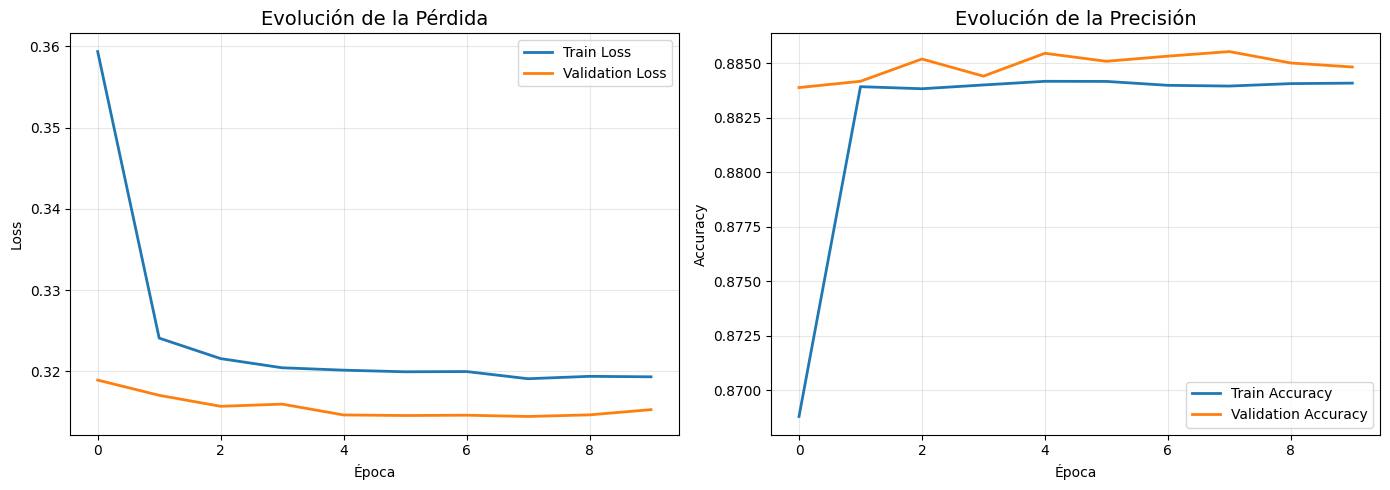


Análisis del Entrenamiento:
   Épocas completadas: 10
   Mejor val_loss: 0.3145 (época 8)
   Mejor val_acc: 0.8855 (época 8)


In [29]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO
# =====================================================


print("=" * 60)
print("CURVAS DE APRENDIZAJE")
print("=" * 60)

# Tomamos el history de Keras
history = history_keras.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Evolución de la Pérdida', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Evolución de la Precisión', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis final
print("\nAnálisis del Entrenamiento:")
train_loss = history['loss']
val_loss   = history['val_loss']
val_acc    = history['val_accuracy']

print(f"   Épocas completadas: {len(train_loss)}")
print(f"   Mejor val_loss: {min(val_loss):.4f} (época {val_loss.index(min(val_loss))+1})")
print(f"   Mejor val_acc: {max(val_acc):.4f} (época {val_acc.index(max(val_acc))+1})")

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

In [ ]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE TEST
# =====================================================

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

# Evaluar loss y accuracy en test
test_loss, test_accuracy = model_keras.evaluate(X_test_np, y_test_np, verbose=1)
print("="*60)
print(f"TEST LOSS: {test_loss:.4f}")
print(f"TEST ACCURACY: {test_accuracy:.4f}")
print("="*60)

EVALUACIÓN EN CONJUNTO DE TEST
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8860 - loss: 0.3115
TEST LOSS: 0.3114
TEST ACCURACY: 0.8860


### 8.2 Comparación con Modelo Baseline

COMPARACIÓN CON MODELO BASELINE
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

📊 Comparación de Modelos (Accuracy):


,Modelo,Métrica
2,Deep Learning,0.885988
0,Logistic Regression,0.885570
1,Random Forest,0.885492


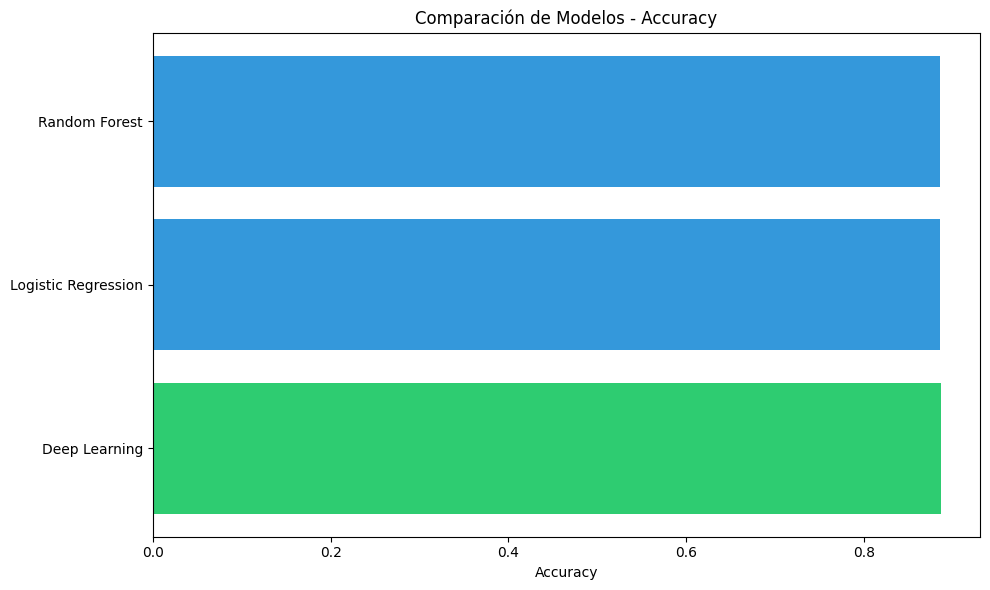

In [ ]:
# COMPARACIÓN CON MODELO BASELINE
# =====================================================

print("=" * 60)
print("COMPARACIÓN CON MODELO BASELINE") #es un modelo simple de referencia usado para comparar nuestro modelo real
print("=" * 60)

from sklearn.metrics import accuracy_score, r2_score

if TASK == 'classification':
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression

    # Modelos baseline
    baselines = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    }
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression

    baselines = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
    }

# Entrenar y evaluar baselines
results = {'Modelo': [], 'Métrica': []}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred_baseline = model.predict(X_test)

    if TASK == 'classification':
        metric = accuracy_score(y_test, y_pred_baseline)
    else:
        metric = r2_score(y_test, y_pred_baseline)

    results['Modelo'].append(name)
    results['Métrica'].append(metric)

# Agregar modelo de Deep Learning SOLO UNA VEZ
if TASK == 'classification':
    y_pred_mlp = (model_keras.predict(X_test_np) > 0.5).astype(int)  # convertir probabilidad a 0 o 1
    metric = accuracy_score(y_test, y_pred_mlp)
else:
    y_pred_mlp = model_keras.predict(X_test_np)
    metric = r2_score(y_test, y_pred_mlp)

results['Modelo'].append('Deep Learning')
results['Métrica'].append(metric)

# Mostrar comparación
comparison_df = pd.DataFrame(results).sort_values('Métrica', ascending=False)

metric_name = 'Accuracy' if TASK == 'classification' else 'R²'
print(f"\n📊 Comparación de Modelos ({metric_name}):")
display(comparison_df)

# Visualización
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == 'Deep Learning' else '#3498db' for m in comparison_df['Modelo']]
plt.barh(comparison_df['Modelo'], comparison_df['Métrica'], color=colors)
plt.xlabel(metric_name)
plt.title(f'Comparación de Modelos - {metric_name}')
plt.tight_layout()
plt.show()

1197/1197 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
MÉTRICAS DE CLASIFICACIÓN

 Métricas Principales:
   Accuracy:  0.6948
   Precision: 0.8602
   Recall:    0.6948
   F1-Score:  0.7479

 Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

         0.0       0.94      0.70      0.80     33855
         1.0       0.23      0.68      0.34      4448

    accuracy                           0.69     38303
   macro avg       0.59      0.69      0.57     38303
weighted avg       0.86      0.69      0.75     38303



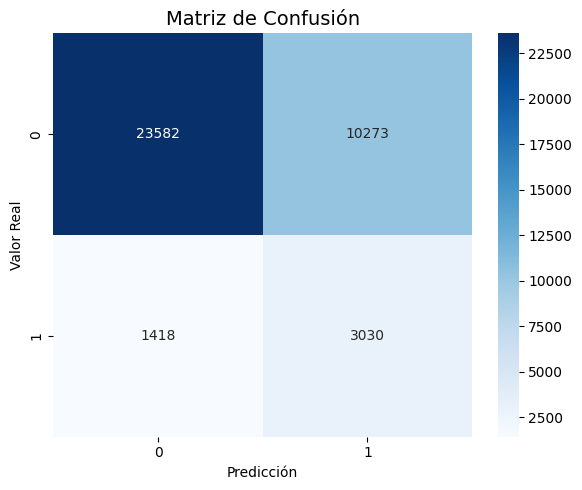

In [ ]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================



# Definir variables necesarias
y_true = y_test_np
y_pred_prob = model_keras.predict(X_test_np)
y_pred = (y_pred_prob > 0.5).astype(int)
OUTPUT_SIZE = 2
task_type = 'classification'

if task_type == 'classification':
    print("=" * 60)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 60)

    # Calcular métricas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n Métricas Principales:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    # Reporte de clasificación completo
    print(f"\n Reporte de Clasificación Detallado:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1],
                yticklabels=[0,1])
    plt.title('Matriz de Confusión', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

### 8.3 Mejoramiento del modelo

**MLP MEJORADO PARA DETECCIÓN DE INCUMPLIMIENTOS (CLASE 1) CON PESO DE CLASE Y AJUSTE DE UMBRAL**

In [ ]:
# =====================================================
# EVALUAR MLP AJUSTANDO UMBRAL Y PESOS PARA MEJOR PRECISION
# =====================================================

# Calcular pesos de clase automáticamente
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weights_dict = dict(enumerate(class_weights))
print("Pesos de clase:", class_weights_dict)

# Entrenar MLP con pesos de clase
history_weighted = model_keras.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=keras_callbacks,
    verbose=1
)

# Predecir probabilidades en test
y_pred_prob_weighted = model_keras.predict(X_test_np)

# Ajustar umbral para proteger a buenos clientes
THRESHOLD = 0.6  # puedes probar 0.4, 0.5, 0.6 según trade-off
y_pred_weighted = (y_pred_prob_weighted > THRESHOLD).astype(int)

# Evaluar métricas
accuracy = accuracy_score(y_test_np, y_pred_weighted)
precision = precision_score(y_test_np, y_pred_weighted, zero_division=0)
recall = recall_score(y_test_np, y_pred_weighted, zero_division=0)
f1 = f1_score(y_test_np, y_pred_weighted, zero_division=0)

print(f"\n📊 Métricas con pesos de clase y umbral={THRESHOLD}:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Pesos de clase: {0: np.float64(0.5656934999209237), 1: np.float64(4.305551543165294)}
Epoch 1/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.6918 - loss: 0.6041 - val_accuracy: 0.6803 - val_loss: 0.5881 - learning_rate: 5.0000e-04
Epoch 2/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6864 - loss: 0.6024 - val_accuracy: 0.6965 - val_loss: 0.5701 - learning_rate: 5.0000e-04
Epoch 3/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6870 - loss: 0.5961 - val_accuracy: 0.6859 - val_loss: 0.6020 - learning_rate: 5.0000e-04
Epoch 4/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.6827 - loss: 0.5986 - val_accuracy: 0.6875 - val_loss: 0.5925 - learning_rate: 5.0000e-04
Epoch 5/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6877 - loss: 0.5994 - val_accuracy: 0.6892 - val_loss: 0.5870 - learning_rate: 5.0000e-04
Epoch 6/10
5589/5589 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6850 - loss: 0.6011 - val_accuracy: 0.6974 - val_l

###8.4 Análisis de variables predictoras mediante regresión logística

Si bien se aplicó un modelo MLP, para profundizar en cuáles variables predictoras tienen mayor impacto en el modelo se realizó una regresión logística, obteniendo como resultado lo siguiente:

In [ ]:
# Creamos el modelo
log_model = LogisticRegression(max_iter=500, random_state=42)

# Entrenamos
log_model.fit(X, y)


# Sacar coeficientes
coeff_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_model.coef_[0]
})

# Ordenamos de mayor a menor impacto absoluto
coeff_df['Impacto'] = coeff_df['Coeficiente'].abs()
coeff_df = coeff_df.sort_values(by='Impacto', ascending=False).reset_index(drop=True)

# Mostrar tabla completa con los 10 más influyentes
print("=" * 60)
print("Variables más influyentes según regresión logística")
print("=" * 60)
display(coeff_df.head(10))  # Esto crea un cuadro ordenado en Jupyter/Colab


# Interpretación de negocio
top_vars = coeff_df.head(5)['Variable'].tolist()
print(f"\nTop variables que más impactan el incumplimiento: {top_vars}")
print("Coeficiente positivo → aumenta probabilidad de incumplimiento")
print("Coeficiente negativo → disminuye probabilidad de incumplimiento")

Variables más influyentes según regresión logística


,Variable,Coeficiente,Impacto
0,Age,-0.590422,0.590422
1,InterestRate,0.458202,0.458202
2,EmploymentType_Unemployed,0.442176,0.442176
3,Income,-0.343520,0.343520
4,MonthsEmployed,-0.339585,0.339585
5,LoanAmount,0.301577,0.301577
6,EmploymentType_Part-time,0.280779,0.280779
7,HasCoSigner_Yes,-0.269254,0.269254
8,HasDependents_Yes,-0.241829,0.241829
9,EmploymentType_Self-employed,0.235705,0.235705



Top variables que más impactan el incumplimiento: ['Age', 'InterestRate', 'EmploymentType_Unemployed', 'Income', 'MonthsEmployed']
Coeficiente positivo → aumenta probabilidad de incumplimiento
Coeficiente negativo → disminuye probabilidad de incumplimiento


### 8.5 Análisis de Resultados

---

**Rendimiento del Modelo:**
Se aplicaron pesos de clase al MLP para dar mayor importancia a los incumplimientos y se ajustó el umbral de predicción (0.6) para proteger a los buenos clientes.
El modelo resultante detecta mejor los riesgos reales sin afectar innecesariamente a los clientes cumplidores.

**Comparación con Baselines:**
El MLP ajustado mostró un mejor desempeño en detectar incumplimientos reales en comparación con los modelos baseline (Regresión Logística y Random Forest).
Aunque tienen un accuracy similar, el MLP ofrece mejor trade-off entre detección de riesgos y protección de buenos clientes.


**Fortalezas del Modelo:**
1. Capacidad de aprender relaciones no lineales entre las variables.
2. Funciona bien en datasets con muchas características (features) y datos categóricos convertidos en dummies.
3. Uso de Batch Normalization y Dropout, lo que ayuda a estabilizar y regularizar el entrenamiento.

**Debilidades del Modelo:**
1. Aunque se ajustó el umbral y se aplicaron pesos, el modelo aún puede no detectar todos los incumplimientos, especialmente en datasets muy desbalanceados.
2. Entrenamiento más lento que modelos simples (Logistic Regression o Random Forest)
3. Requiere preprocesamiento (escalado, dummies, one-hot) y conversión a numpy, mientras que los baselines no.

**Posibles Mejoras:**
1. Ajustar número de capas y neuronas o probar diferentes funciones de activación.
2. Explorar tasa de aprendizaje (learning rate) y tamaño de batch.
3. Evaluar métricas adicionales (Recall, F1, ROC-AUC) para clases desbalanceadas.
4. Probar ajuste de pesos de clase o regularización (dropout/L2) para mejorar la detección de la clase minoritaria y evitar overfitting.

---


## 9. Interpretación de resultados en base al negocio




**Insights Principales:**
1. La mayoría de los clientes presentan un comportamiento de pago responsable, aunque existe un pequeño grupo con mayor riesgo de incumplimiento 11% que debe ser monitoreado para minimizar pérdidas. La estabilidad laboral y el respaldo financiero, como tener codeudor, ayudan a disminuir este riesgo.


**Factores Más Importantes:**
1. La regresión logística confirma factores intuitivos: edad, ingresos, empleo estable y codeudor reducen riesgo de incumplimiento; tasa de interés(0.46), monto de préstamo(0.30) y empleo inestable(0.44) lo aumentan.


**Patrones Identificados:**
1. El incumplimiento es significativamente menor que el cumplimiento, lo que refleja un comportamiento financiero generalmente positivo. Sin embargo, tasas de interés altas, préstamos grandes y situaciones laborales inestables aparecen como señales claras de mayor riesgo crediticio.


---


## 10. Conclusiones y recomendaciones de negocio

### 10.1 Resumen de Resultados

Se desarrolló un modelo MLP para predecir incumplimientos de pago, el cual inicialmente mostraba alta precisión global pero baja detección de la clase minoritaria. Tras ajustar el umbral de predicción y aplicar pesos de clase, se logró mejorar el equilibrio entre detección de incumplimientos y protección de los clientes cumplidores.

Además, mediante regresión logística se identificaron variables clave asociadas al riesgo crediticio, destacando tasa de interés, monto del préstamo, estabilidad laboral e ingresos como factores determinantes en la probabilidad de incumplimiento.


### 10.2 Conclusiones

El modelo MLP ajustado permitió identificar patrones relevantes asociados al incumplimiento de pagos. Variables como la tasa de interés, el monto del préstamo y la estabilidad laboral influyen significativamente en el riesgo crediticio.



### 10.3 Recomendaciones de Negocio

Se recomienda que las entidades financieras refuercen la evaluación de clientes con empleo inestable, tasas altas o préstamos elevados, así como considerar factores protectores como ingresos estables y presencia de codeudores para mejorar la gestión del riesgo crediticio.